## Setting

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
# ── Paths ──────────────────────────────────────────────────
EMB_DIR = Path("../data/processed/embeddings")
CP_DIR = Path("../results/cp")
NETWORKS_DIR = Path("../data/processed/networks_emb")
OUT_DIR = Path("../results/figures")

# ── Time ───────────────────────────────────────────────────
YEAR_START = 1990
YEAR_END   = 2023
YEARS      = list(range(YEAR_START, YEAR_END + 1))
YEAR_TICKS = list(range(YEAR_START, YEAR_END + 1, 5))
T          = len(YEARS)
SOURCES    = ['news', 'paper']
EDGE_THRESHOLDS = {"news": 0.0, "paper": 0.5}

# ── Colors ─────────────────────────────────────────────────
NEWS_COLOR    = 'crimson'
PAPER_COLOR   = 'mediumblue'
SOURCE_COLORS = {'news': NEWS_COLOR, 'paper': PAPER_COLOR}

# ── Key Events ─────────────────────────────────────────────
KEY_EVENTS = {
    1995: 'SVM',
    1997: 'Deep Blue',
    2001: 'LIBSVM',
    2006: 'NVIDIA CUDA',
    2011: 'IBM Watson',
    2012: 'AlexNet',
    2014: 'GANs',
    2016: 'AlphaGo',
    2017: 'Transformer',
    2020: 'GPT-3/AlphaFold2',
    2022: 'ChatGPT',
}

def add_events(ax, ypos_frac=0.97, fontsize=6,
               color='#888888', lw=0.8):
    ylim = ax.get_ylim()
    ypos = ylim[0] + (ylim[1] - ylim[0]) * ypos_frac
    for yr, label in KEY_EVENTS.items():
        if YEAR_START <= yr <= YEAR_END:
            ax.axvline(yr, color=color, lw=lw,
                       ls='--', alpha=0.6, zorder=0)
            ax.text(yr + 0.15, ypos, label,
                    fontsize=fontsize, rotation=90,
                    va='top', color=color, alpha=0.8)


# ── 시기 구분 ────────────────────────────────────────────────────────────
# 하드코딩하지 않고, 03_temporal_identification.ipynb §3.8 가 데이터에서 추정한 경계를 읽는다.
# 03을 먼저 실행해야 한다.
from pathlib import Path as _Path
import ast as _ast

PERIOD_CSV     = _Path("../results/cp/periodization/periodization_main.csv")
PERIOD_VARIANT = "detrended"   # 부트스트랩 K=3 0.908, news 단독과 완전 일치
PERIOD_SPEC    = "joint"    # "joint" | "news" | "paper"
PERIOD_LABELS  = {}         # 예: {1: "P1", 2: "P2"} — 비우면 P1, P2, ... 자동
YEAR_RANGE     = (1991, 2023)   # 1990은 C·D가 결측이라 시기 구분에서 제외

def load_periods(csv=PERIOD_CSV, variant=PERIOD_VARIANT, spec=PERIOD_SPEC,
                 years=YEAR_RANGE, labels=None):
    """03번 §3.8이 추정한 경계를 읽어 [(start, end, label), ...] 로 만든다."""
    if not csv.exists():
        raise FileNotFoundError(
            f"시기 구분 결과가 없습니다: {csv}\n"
            "03_temporal_identification.ipynb §3.8 를 먼저 실행하세요.")
    df  = pd.read_csv(csv)
    row = df[(df["variant"] == variant) & (df["spec"] == spec)]
    if row.empty:
        raise ValueError(
            f"variant={variant!r}, spec={spec!r} 조합이 없습니다. "
            f"가능한 값: {sorted(set(zip(df['variant'], df['spec'])))}")
    bnds = row["boundaries"].iloc[0]
    if isinstance(bnds, str):
        bnds = _ast.literal_eval(bnds)
    bnds = sorted(int(b) for b in bnds if years[0] < int(b) <= years[1])
    edges = [years[0]] + bnds + [years[1] + 1]
    labels = labels or PERIOD_LABELS
    return [(edges[i], edges[i + 1] - 1, labels.get(i + 1, f"P{i + 1}"))
            for i in range(len(edges) - 1)]

AI_PERIODS = load_periods()
print("시기 구분 (03번 §3.8 산출, "
      f"variant={PERIOD_VARIANT} spec={PERIOD_SPEC}):")
for a, b, lab in AI_PERIODS:
    print(f"   {lab}  {a}–{b}")

def add_period_bands(ax, color="#D9D9D9", alpha=0.18):
    for i, (start, end, _) in enumerate(AI_PERIODS):
        if i % 2 == 0:
            ax.axvspan(start, end, color=color, alpha=alpha, zorder=-10)
            

시기 구분 (03번 §3.8 산출, variant=raw spec=joint):
   P1  1991–1997
   P2  1998–2002
   P3  2003–2008
   P4  2009–2013
   P5  2014–2018
   P6  2019–2023


## CP plot

### Data load & functions

In [3]:
# 데이터 로드
news_df = pd.read_csv(CP_DIR / f"news_cp_metrics_t{EDGE_THRESHOLDS['news']}_symnorm.csv")
paper_df = pd.read_csv(CP_DIR / f"paper_cp_metrics_t{EDGE_THRESHOLDS['paper']}_symnorm.csv")

In [4]:
def plot_metric(ax, df, measure, ci_col, color, ylabel, ylim, title_label, math_label, year_ticks, pct=False):
    add_period_bands(ax)
    plot_df = df.dropna(subset=[measure])
    sns.lineplot(data=plot_df, x="year", y=measure, color=color, errorbar=None, ax=ax)
    ax.fill_between(plot_df["year"],
                    plot_df[measure] - plot_df[ci_col],
                    plot_df[measure] + plot_df[ci_col],
                    color=color, alpha=0.2)
    ax.set_xlim(YEAR_START, YEAR_END)
    ax.set_xticks(YEAR_TICKS)
    ax.set_ylim(*ylim)
    ax.set_aspect(1 / ax.get_data_ratio())
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    add_events(ax, fontsize=8)
    if pct:
        ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1.0))
    ax.set_title(rf"${{({title_label})}}$", loc="left")
    # ax.text(0.95, 0.85, f"${math_label}$",
    #         transform=ax.transAxes,
    #         horizontalalignment="right",
    #         size=20)


def plot_metric_delta(ax, df, measure, ci_col, color, ylabel, ylim, title_label, math_label, year_ticks, pct=False):
    add_period_bands(ax)
    plot_df = df.sort_values("year").dropna(subset=[measure]).copy()
    
    rate_col = f"{measure}_growth_rate"
    rate_ci_col = f"{ci_col}_growth_rate"

    prev = plot_df[measure].shift(1)
    prev_ci = plot_df[ci_col].shift(1)

    plot_df[rate_col] = (plot_df[measure] - prev) / prev

    # CI 근사: r = I_t / I_t-1 - 1 기준 error propagation
    plot_df[rate_ci_col] = np.sqrt(
        (plot_df[ci_col] / prev) ** 2 +
        ((plot_df[measure] * prev_ci) / (prev ** 2)) ** 2
    )

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=[rate_col, rate_ci_col])
    
    sns.lineplot(data=plot_df, x="year", y=rate_col, color=color, errorbar=None, ax=ax)
    ax.fill_between(plot_df["year"],
                    plot_df[rate_col] - plot_df[rate_ci_col],
                    plot_df[rate_col] + plot_df[rate_ci_col],
                    color=color, alpha=0.2)
    ax.axhline(0, color="gray", linewidth=1, linestyle="-", alpha=0.8)
    ax.set_xlim(YEAR_START, YEAR_END)
    ax.set_xticks(YEAR_TICKS)
    ax.set_ylim(*ylim)
    ax.set_aspect(1 / ax.get_data_ratio())
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    add_events(ax, fontsize=8)
    
    if pct:
        ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1.0))
    ax.set_title(rf"${{({title_label})}}$", loc="left")
    # ax.text(0.95, 0.85, f"${math_label}$",
    #         transform=ax.transAxes,
    #         horizontalalignment="right",
    #         size=24)


### Raw index

In [5]:
# Figure 3.3. Structural indices over time in social and scientific domains
OUT_DIR.mkdir(parents=True, exist_ok=True)

STRUCTURAL_COLORS = {
    'cit': '#FF1F5B',          # Churn of core nodes
    'rit': '#00CD6C',          # Relative number of core nodes
    'sit': '#009ADE',          # Number of cores
    'herfindahl': '#AF58BA',   # Concentration
}

paper_configs = [
    (paper_df, 'cit_mean',        'cit_ci',        STRUCTURAL_COLORS['cit'],        'Churn of Core Nodes',      (0.4, 0.7),    'a', 'C_{it}', False),
    (paper_df, 'rit_mean',        'rit_ci',        STRUCTURAL_COLORS['rit'],        'Relat. No. of Core Nodes', (0.35, 0.45),  'b', 'R_{it}', True),
    (paper_df, 'sit_mean',        'sit_ci',        STRUCTURAL_COLORS['sit'],        'No. of Cores',             (1000, 2300),  'c', 'S_{it}', False),
    (paper_df, 'herfindahl_mean', 'herfindahl_ci', STRUCTURAL_COLORS['herfindahl'], 'Concentration',            (0.00, 0.23),  'd', 'H_{it}', False),
]

news_configs = [
    (news_df, 'cit_mean',        'cit_ci',        STRUCTURAL_COLORS['cit'],        'Churn of Core Nodes',      (0.4, 0.7),   'e', 'C_{it}', False),
    (news_df, 'rit_mean',        'rit_ci',        STRUCTURAL_COLORS['rit'],        'Relat. No. of Core Nodes', (0.5, 0.7),   'f', 'R_{it}', True),
    (news_df, 'sit_mean',        'sit_ci',        STRUCTURAL_COLORS['sit'],        'No. of Cores',             (0, 1300),    'g', 'S_{it}', False),
    (news_df, 'herfindahl_mean', 'herfindahl_ci', STRUCTURAL_COLORS['herfindahl'], 'Concentration',            (0.00, 0.23), 'h', 'H_{it}', False),
]


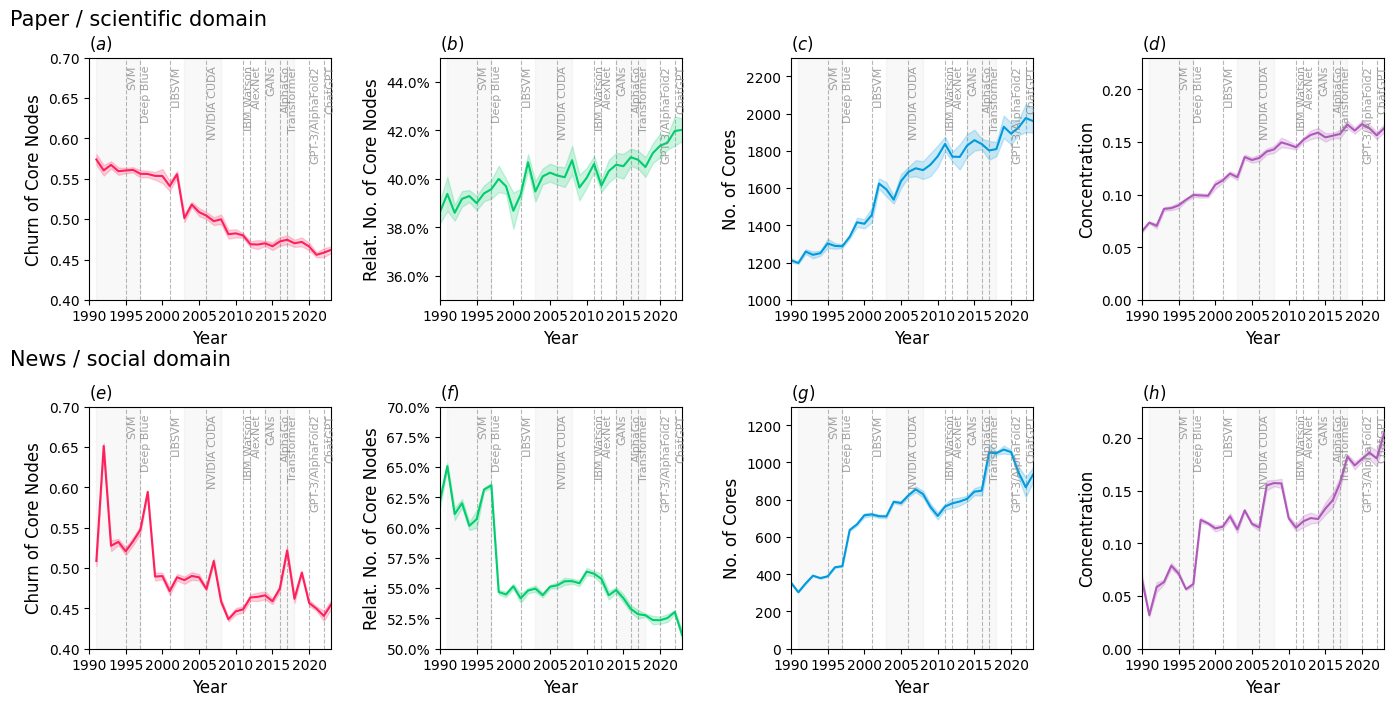

In [6]:
fig, axs = plt.subplots(2, 4, figsize=(14, 7))

for col, config in enumerate(paper_configs):
    df, measure, ci_col, color, ylabel, ylim, title, math, pct = config
    plot_metric(axs[0, col], df, measure, ci_col, color, ylabel, ylim, title, math, YEAR_TICKS, pct=pct)

for col, config in enumerate(news_configs):
    df, measure, ci_col, color, ylabel, ylim, title, math, pct = config
    plot_metric(axs[1, col], df, measure, ci_col, color, ylabel, ylim, title, math, YEAR_TICKS, pct=pct)

fig.text(0.005, 0.49,  'News / social domain', fontsize=15, transform=fig.transFigure)
fig.text(0.005, 0.975, 'Paper / scientific domain', fontsize=15, transform=fig.transFigure)

plt.tight_layout(rect=(0.005, 0, 1, 0.98), h_pad=3, w_pad=2)
plt.savefig(OUT_DIR / 'fig_cp_indices.png', bbox_inches='tight', dpi=300)
plt.show()

### Delta

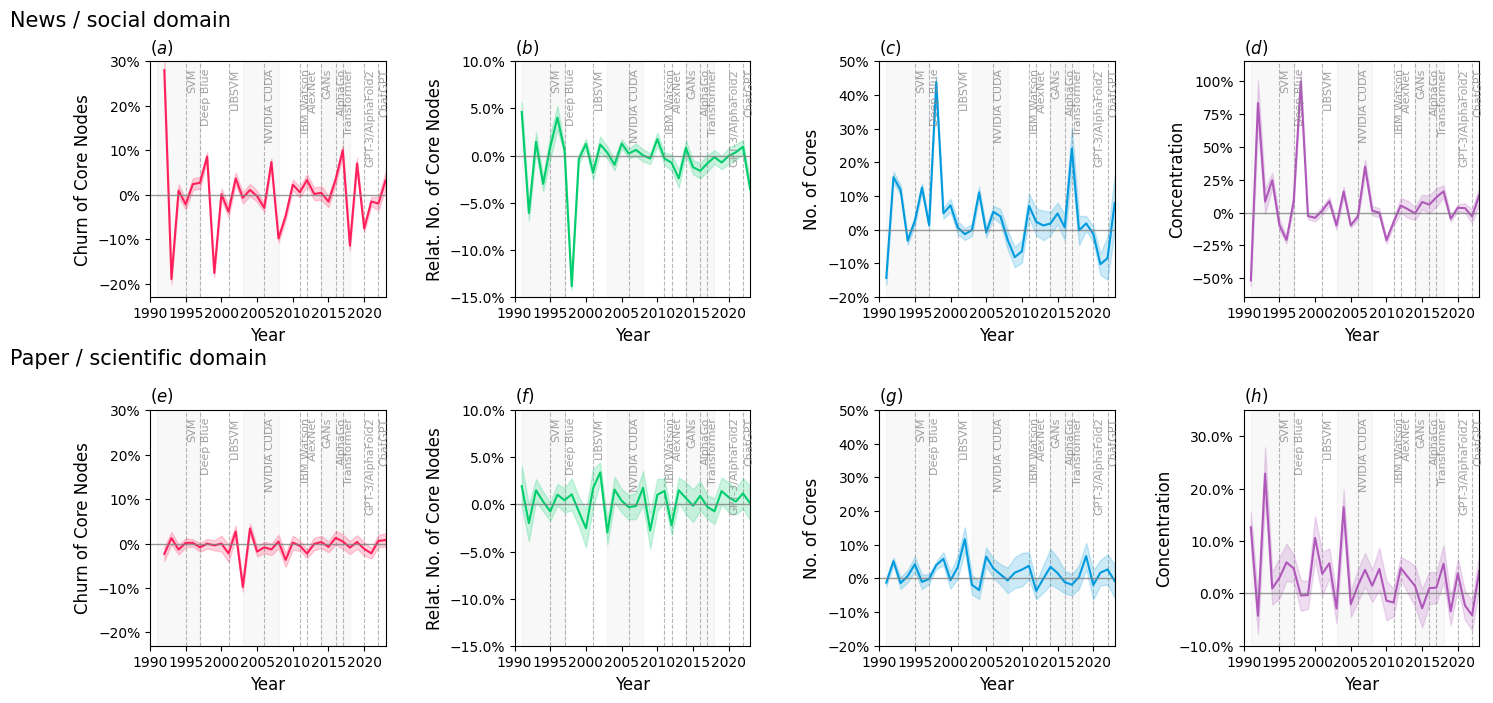

In [7]:
# Optional: delta version of the structural indices, kept separate from embedding drift
OUT_DIR.mkdir(parents=True, exist_ok=True)

if 'STRUCTURAL_COLORS' not in globals():
    STRUCTURAL_COLORS = {
        'cit': '#FF1F5B',
        'rit': '#00CD6C',
        'sit': '#009ADE',
        'herfindahl': '#AF58BA',
    }

news_delta_configs = [
    (news_df, 'cit_mean',        'cit_ci',        STRUCTURAL_COLORS['cit'],        'Churn of Core Nodes',      (-0.23, 0.30), 'a', 'C_{it}', True),
    (news_df, 'rit_mean',        'rit_ci',        STRUCTURAL_COLORS['rit'],        'Relat. No. of Core Nodes', (-0.15, 0.10), 'b', 'R_{it}', True),
    (news_df, 'sit_mean',        'sit_ci',        STRUCTURAL_COLORS['sit'],        'No. of Cores',             (-0.20, 0.50), 'c', 'S_{it}', True),
    (news_df, 'herfindahl_mean', 'herfindahl_ci', STRUCTURAL_COLORS['herfindahl'], 'Concentration',            (None, None),  'd', 'H_{it}', True),
]

paper_delta_configs = [
    (paper_df, 'cit_mean',        'cit_ci',        STRUCTURAL_COLORS['cit'],        'Churn of Core Nodes',      (-0.23, 0.30), 'e', 'C_{it}', True),
    (paper_df, 'rit_mean',        'rit_ci',        STRUCTURAL_COLORS['rit'],        'Relat. No. of Core Nodes', (-0.15, 0.10), 'f', 'R_{it}', True),
    (paper_df, 'sit_mean',        'sit_ci',        STRUCTURAL_COLORS['sit'],        'No. of Cores',             (-0.20, 0.50), 'g', 'S_{it}', True),
    (paper_df, 'herfindahl_mean', 'herfindahl_ci', STRUCTURAL_COLORS['herfindahl'], 'Concentration',            (-0.10, 0.35), 'h', 'H_{it}', True),
]

fig, axs = plt.subplots(2, 4, figsize=(15, 7))

for col, config in enumerate(news_delta_configs):
    df, measure, ci_col, color, ylabel, ylim, title, math, pct = config
    plot_metric_delta(axs[0, col], df, measure, ci_col, color, ylabel, ylim, title, math, YEAR_TICKS, pct=pct)

for col, config in enumerate(paper_delta_configs):
    df, measure, ci_col, color, ylabel, ylim, title, math, pct = config
    plot_metric_delta(axs[1, col], df, measure, ci_col, color, ylabel, ylim, title, math, YEAR_TICKS, pct=pct)

fig.text(0.005, 0.975, 'News / social domain', fontsize=15, transform=fig.transFigure)
fig.text(0.005, 0.49, 'Paper / scientific domain', fontsize=15, transform=fig.transFigure)

plt.tight_layout(rect=(0.035, 0, 1, 0.98), h_pad=3, w_pad=2)
plt.savefig(OUT_DIR / 'cp_dynamics_structural_indices_delta.png', bbox_inches='tight', dpi=300)
plt.show()


## Embedding plot

### pre-compute

In [8]:
# ── Vocab ──────────────────────────────────────────────────
with open(NETWORKS_DIR / 'global_subjects_filtered.pkl', 'rb') as f:
    subjects = pickle.load(f)
subj_idx = {s: i for i, s in enumerate(subjects)}
N = len(subjects)
print(f'N={N:,}, T={T}')

N=29,312, T=34


In [9]:
# ── 1-1. Unit norm ─────────────────────────────────────────
emb  = {}
attn = {}

for src in SOURCES:
    raw = torch.load(
        EMB_DIR / f'{src}_embeddings.pt',
        map_location='cpu')
    emb[src] = F.normalize(raw, p=2, dim=-1)  # [T, N, 32]
    attn[src] = torch.load(
        EMB_DIR / f'{src}_temporal_attn.pt',
        map_location='cpu')                    # [N, T, T]
    print(f'{src}: emb {tuple(emb[src].shape)}, '
          f'attn {tuple(attn[src].shape)}')

news: emb (34, 29312, 32), attn (29312, 34, 34)
paper: emb (34, 29312, 32), attn (29312, 34, 34)


In [10]:
# ── 1-2. L2 Drift ──────────────────────────────────────────
def compute_l2_drift(emb_norm: torch.Tensor) -> torch.Tensor:
    """[T, N, D] -> [T-1, N]"""
    return (emb_norm[1:] - emb_norm[:-1]).norm(dim=-1)

drift = {src: compute_l2_drift(emb[src]) for src in SOURCES}

for src in SOURCES:
    d = drift[src].numpy()
    print(f'{src}: median={np.median(d):.4f}, '
          f'p90={np.percentile(d, 90):.4f}')

news: median=0.0508, p90=0.2161
paper: median=0.0494, p90=0.4666


In [11]:
# ── 1-3. Co-occ degree ─────────────────────────────────────
def load_cooc_degree(source: str) -> np.ndarray:
    """[T, N]"""
    mat = np.zeros((T, N), dtype=np.float32)
    for t, yr in enumerate(
            tqdm(YEARS, desc=f'{source} cooc')):
        adj = sp.load_npz(
            NETWORKS_DIR / f'{source}_{yr}_adj_f.npz')
        mat[t] = np.asarray(adj.sum(axis=1)).ravel()
    return mat

cooc_degree = {
    src: load_cooc_degree(src) for src in SOURCES
}

news cooc:   0%|          | 0/34 [00:00<?, ?it/s]

paper cooc:   0%|          | 0/34 [00:00<?, ?it/s]

### Final figure panels


In [12]:
def plot_drift_panel(ax, src, color, title_label=None, panel_title=None, ylim=None):
    add_period_bands(ax)

    d = drift[src].detach().cpu().numpy()  # [T-1, N]
    q25, q50, q75 = np.nanpercentile(d, [25, 50, 75], axis=1)

    ax.fill_between(YEARS[1:], q25, q75, color=color, alpha=0.18, linewidth=0)
    ax.plot(YEARS[1:], q50, color=color, lw=2.2)

    ax.set_xlim(YEAR_START + 1, YEAR_END)
    ax.set_xticks(YEAR_TICKS)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Embedding drift', fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(alpha=0.25)

    add_events(ax, fontsize=7)

    if panel_title is not None:
        ax.set_title(panel_title, loc='left', fontsize=12)
    elif title_label is not None:
        ax.set_title(rf'$({title_label})$', loc='left')


In [13]:
# Structural indices are generated in the CP plot section above.
# Embedding drift is combined with temporal attention in the Attention plot section below.


In [14]:
# The previous drift-plus-structural combined figure is intentionally removed.
# This keeps Figure 3.3 as two separate panels: structural indices, then drift + temporal attention.


## Attention plot

In [15]:
YEAR_TO_POS = {y: i for i, y in enumerate(YEARS)}

def add_period_boundaries_heatmap(ax, line_color='black', lw=0.9, alpha=0.45, both_axes=True):
    for start, _, _ in AI_PERIODS[1:]:
        if start in YEAR_TO_POS:
            b = YEAR_TO_POS[start] - 0.5
            ax.axvline(b, color=line_color, lw=lw, alpha=alpha, zorder=4)
            if both_axes:
                ax.axhline(b, color=line_color, lw=lw, alpha=alpha, zorder=4)


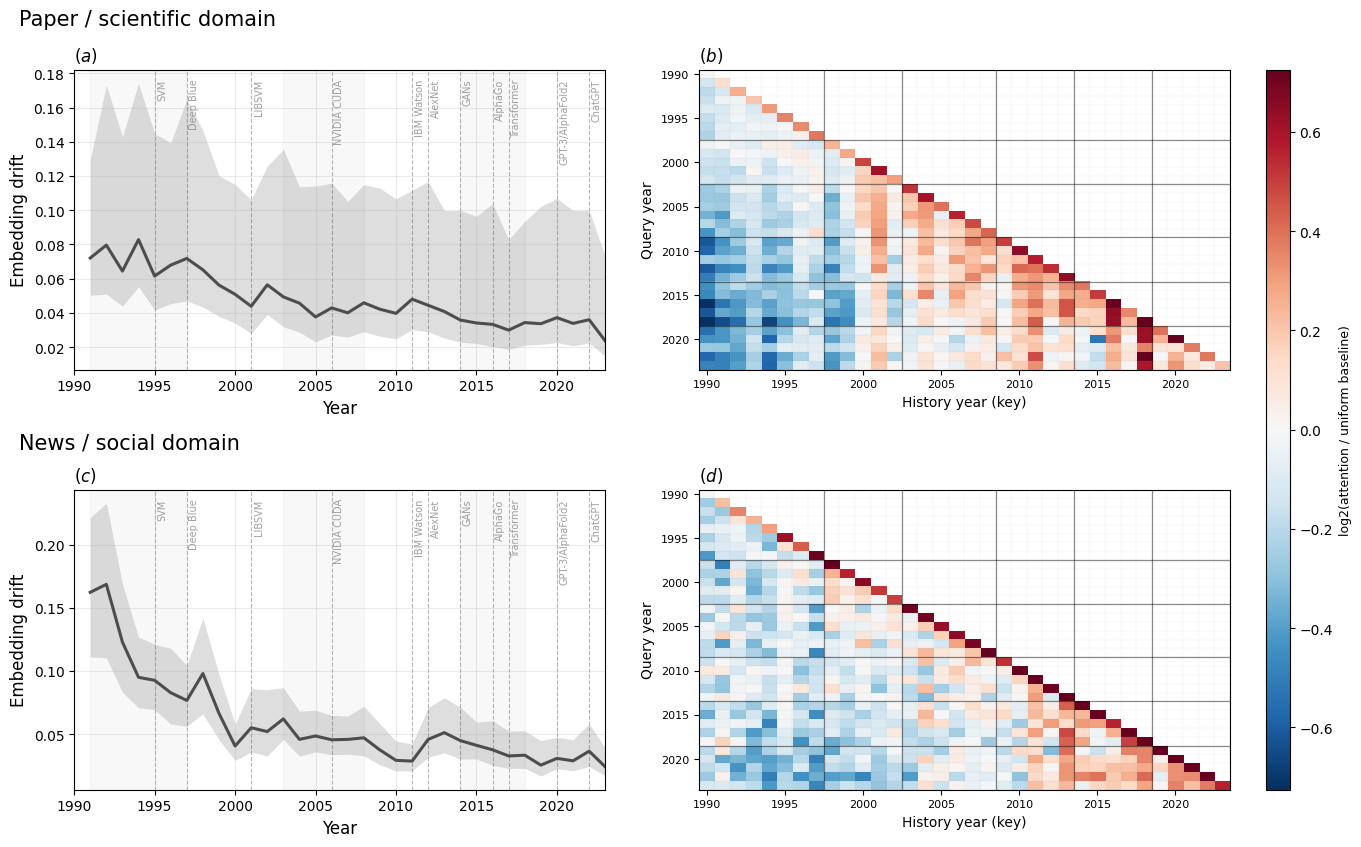

In [16]:
def attention_over_uniform(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Softmaxed causal attention [T, T] -> log2(attention / uniform causal baseline)."""
    A = np.asarray(A, dtype=float)
    T = A.shape[0]
    out = np.full_like(A, np.nan, dtype=float)

    for t in range(T):
        baseline = 1.0 / (t + 1)
        out[t, :t+1] = np.log2((A[t, :t+1] + eps) / baseline)

    return out


def plot_attention_panel(ax, src, attn_matrix, norm, cmap, title):
    im = ax.imshow(attn_matrix, aspect='auto', origin='upper', cmap=cmap, norm=norm, interpolation='nearest')
    add_period_boundaries_heatmap(ax)

    t_local = len(YEARS)
    tick_pos = [k for k, y in enumerate(YEARS) if y % 5 == 0]
    tick_label = [str(YEARS[k]) for k in tick_pos]

    ax.set_xticks(np.arange(-0.5, t_local, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, t_local, 1), minor=True)
    ax.grid(which='minor', color='gray', lw=0.1, alpha=0.45)
    ax.tick_params(which='minor', bottom=False, left=False)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_label, fontsize=8)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(tick_label, fontsize=8)
    ax.tick_params(axis='y', labelleft=True)

    ax.set_xlabel('History year (key)', fontsize=10)
    ax.set_ylabel('Query year', fontsize=10)
    ax.set_title(title, loc='left', fontsize=12)
    return im


# Figure 3.3. Embedding drift and temporal attention in paper and news networks
OUT_DIR.mkdir(parents=True, exist_ok=True)

attn_excess = {
    src: attention_over_uniform(attn[src].mean(dim=0).detach().cpu().numpy())
    for src in SOURCES
}

vmax = max(np.nanpercentile(np.abs(attn_excess[src]), 98) for src in SOURCES)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color='white')

DRIFT_COLOR = '#4D4D4D'  # neutral drift color to avoid confusion with the attention heatmap

fig = plt.figure(figsize=(13.5, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 1.0, 0.045], wspace=0.08, hspace=0.06)

panel_specs = [
    ('paper', 'Paper / scientific domain', 'a', 'b'),
    ('news',  'News / social domain',      'c', 'd'),
]

last_im = None
for row, (src, domain_label, drift_label, attn_label) in enumerate(panel_specs):
    ax_drift = fig.add_subplot(gs[row, 0])
    ax_attn = fig.add_subplot(gs[row, 1])

    plot_drift_panel(
        ax_drift,
        src,
        color=DRIFT_COLOR,
        panel_title=rf'$({drift_label})$'
    )

    last_im = plot_attention_panel(
        ax_attn,
        src,
        attn_excess[src],
        norm,
        cmap,
        title=rf'$({attn_label})$'
    )

cax = fig.add_subplot(gs[:, 2])
cbar = fig.colorbar(last_im, cax=cax)
cbar.set_label('log2(attention / uniform baseline)', fontsize=9)
cbar.ax.tick_params(labelsize=10)

fig.text(0.01, 1.02,  'Paper / scientific domain', fontsize=15, transform=fig.transFigure)
fig.text(0.01, 0.49, 'News / social domain', fontsize=15, transform=fig.transFigure)

plt.savefig(OUT_DIR / 'fig_emb_att.png', dpi=300, bbox_inches='tight')
plt.show()


## Element plot

In [17]:
# ── Element-group plot helpers ─────────────────────────────
ELEMENT_QUERIES = {
    "artificial intelligence": ("artificial intelligence", 20),
    "deep learning": ("deep learning", 20),
    "machine learning": ("machine learning", 20),
    "neural network": ("neural network", 20),
    "privacy": ("privacy", 20),
    "employment": ("employment", 20),
    "bias": ("bias", 20),
    "automobile": ("automobile", 20),
    "pharmaceutic": ("pharmaceutic", 20),
    "automation": ("automation", 20),
}

def get_group_terms(query, top_k=None, src=None, verbose=True):
    q = query.lower()
    hits = [s for s in subjects if q in s.lower()]

    if src is not None:
        if src not in SOURCES:
            raise ValueError(f"unknown src: {src}")
        hits = [s for s in hits if np.nansum(cooc_degree[src][:, subj_idx[s]]) > 0]

    def degree_score(s):
        idx = subj_idx[s]
        if src is None:
            return sum(np.nansum(cooc_degree[x][:, idx]) for x in SOURCES)
        return np.nansum(cooc_degree[src][:, idx])

    hits = sorted(hits, key=degree_score, reverse=True)
    terms = hits if top_k is None else hits[:top_k]

    if verbose:
        scope = "pooled" if src is None else src
        print(f"'{query}' [{scope}] -> hits={len(hits):,}, using={len(terms):,}")
        for s in terms[:10]:
            print(f"  [{subj_idx[s]:6d}] {s}  score={degree_score(s):.1f}")

    return terms
    
def get_group_idxs(terms, verbose=False):
    """
    term 리스트 -> (subj_idx 기준 인덱스 리스트, 매칭 실패한 term 리스트)
    - 입력 순서 유지, 중복 제거
    - 정확 매칭 실패 시 소문자/공백 정규화로 재시도
    """
    if isinstance(terms, str):
        terms = [terms]

    # 소문자 정규화 lookup (최초 1회만 생성해 재사용)
    global _SUBJ_IDX_LOWER
    if '_SUBJ_IDX_LOWER' not in globals():
        _SUBJ_IDX_LOWER = {}
        for s, i in subj_idx.items():
            _SUBJ_IDX_LOWER.setdefault(s.strip().lower(), i)

    idxs, missing, seen = [], [], set()
    for t in terms:
        if t in subj_idx:
            idx = subj_idx[t]
        else:
            idx = _SUBJ_IDX_LOWER.get(str(t).strip().lower())

        if idx is None:
            missing.append(t)
            continue
        if idx in seen:
            continue
        seen.add(idx)
        idxs.append(idx)

    if verbose:
        print(f"matched={len(idxs):,} / requested={len(terms):,}, missing={len(missing):,}")

    return idxs, missing

def group_attention_excess(src, idxs):
    A = attn[src][idxs].mean(dim=0).detach().cpu().numpy()
    return attention_over_uniform(A)

'artificial intelligence' [pooled] -> hits=11, using=11
  [  1472] artificial intelligence  score=113472.7
  [  1148] anticipation (artificial intelligence)  score=25345.1
  [  1267] applications of artificial intelligence  score=5094.0
  [ 11180] generative artificial intelligence  score=1530.9
  [  1473] artificial intelligence system  score=974.0
  [  1474] artificial intelligence, situated approach  score=845.0
  [ 17412] music and artificial intelligence  score=406.0
  [   563] agents (artificial intelligence)  score=8.0
  [  8297] editorials -- artificial intelligence  score=7.0
  [ 14456] knowledge bases (artificial intelligence)  score=4.2


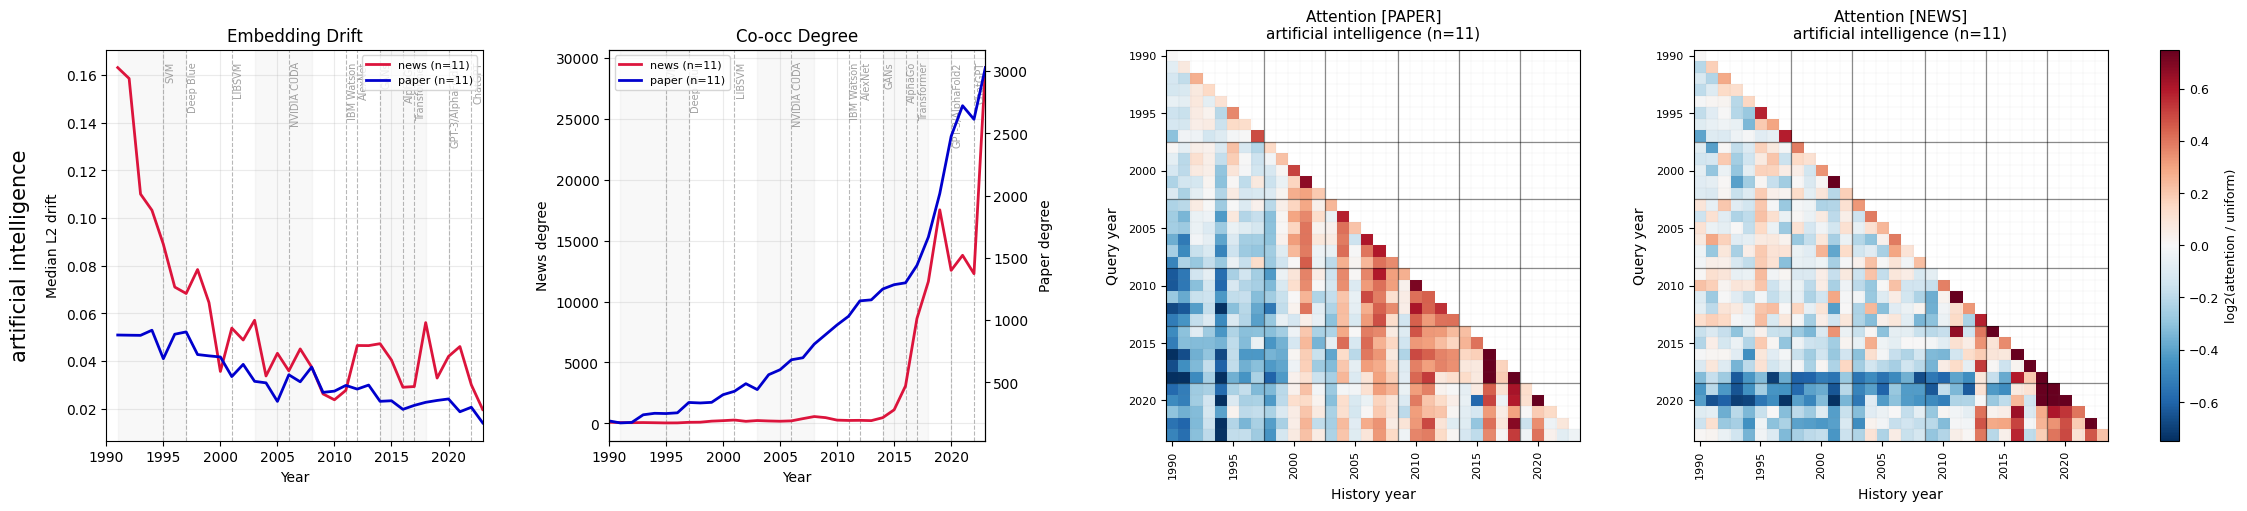

'deep learning' [pooled] -> hits=1, using=1
  [  6868] deep learning  score=279168.4


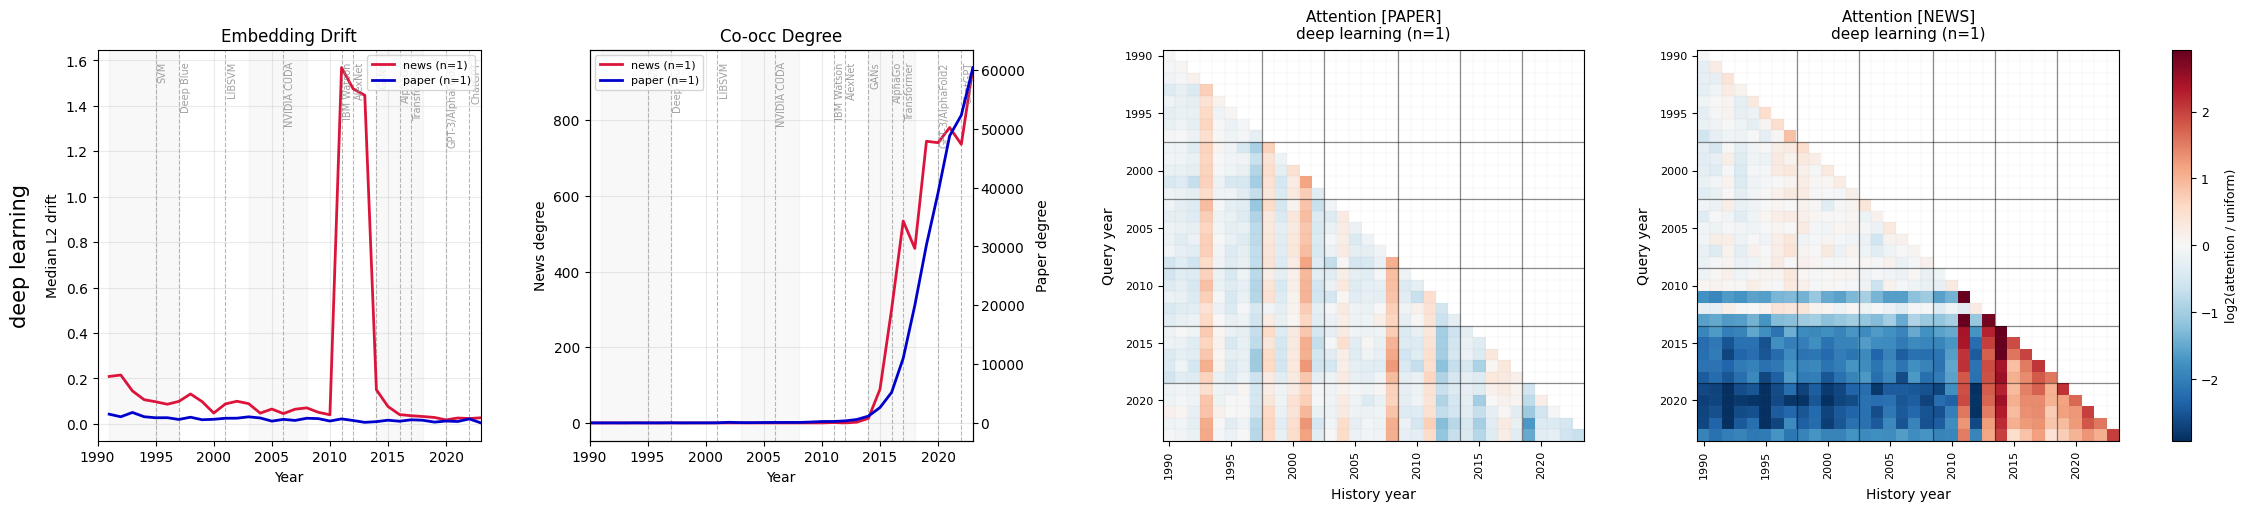

'machine learning' [pooled] -> hits=5, using=5
  [   291] active learning (machine learning)  score=37298.0
  [ 15616] machine learning  score=33534.0
  [  2892] boosting (machine learning)  score=33204.0
  [ 15854] margin (machine learning)  score=25114.0
  [ 23670] semantic analysis (machine learning)  score=2771.0


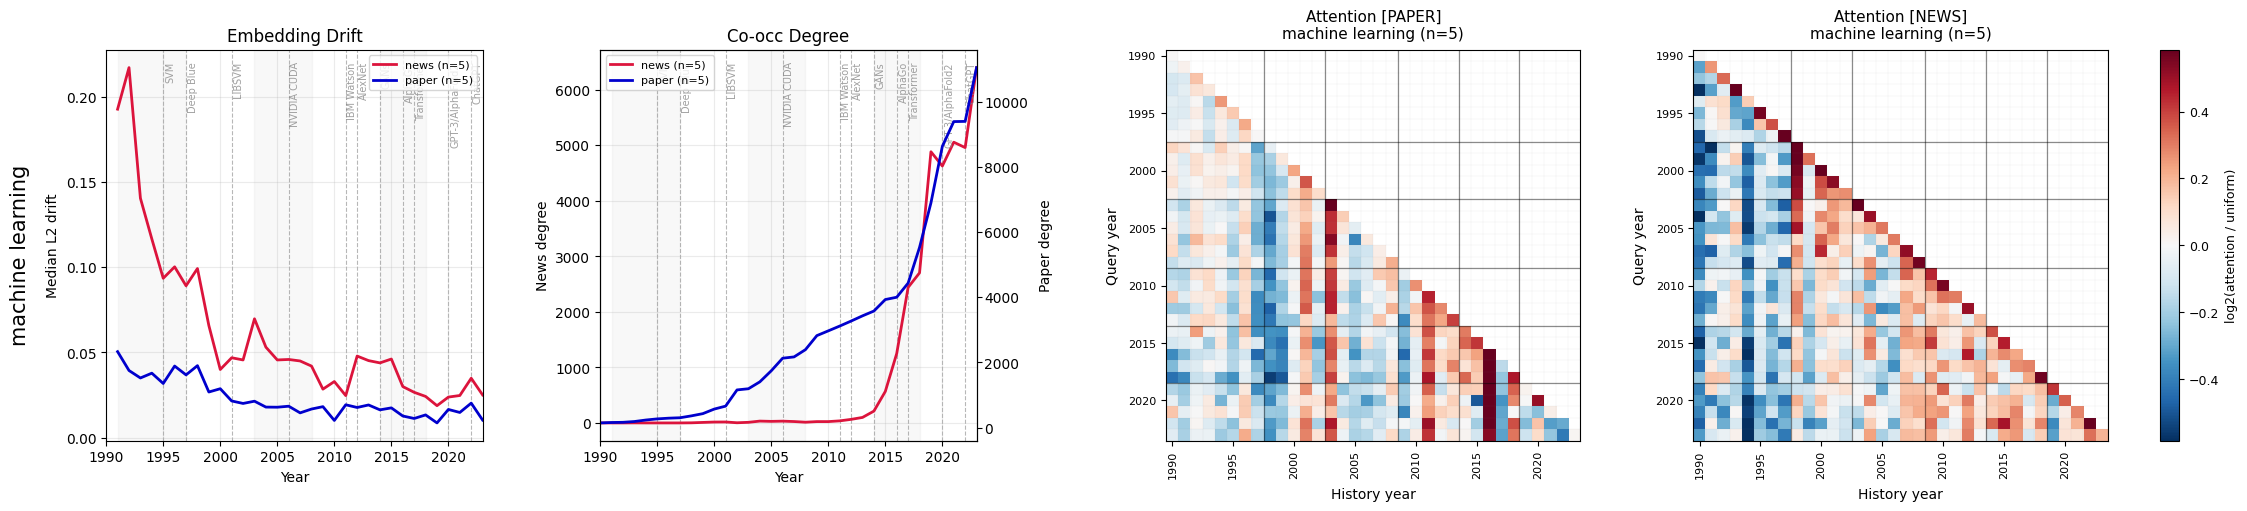

'neural network' [pooled] -> hits=6, using=6
  [  1479] artificial neural network  score=875375.9
  [  5763] convolutional neural network  score=222719.2
  [  7928] dropout (neural networks)  score=8213.0
  [ 17863] neural networks  score=7612.5
  [  2514] biological neural network  score=4557.0
  [  1480] artificial neural networks  score=7.5


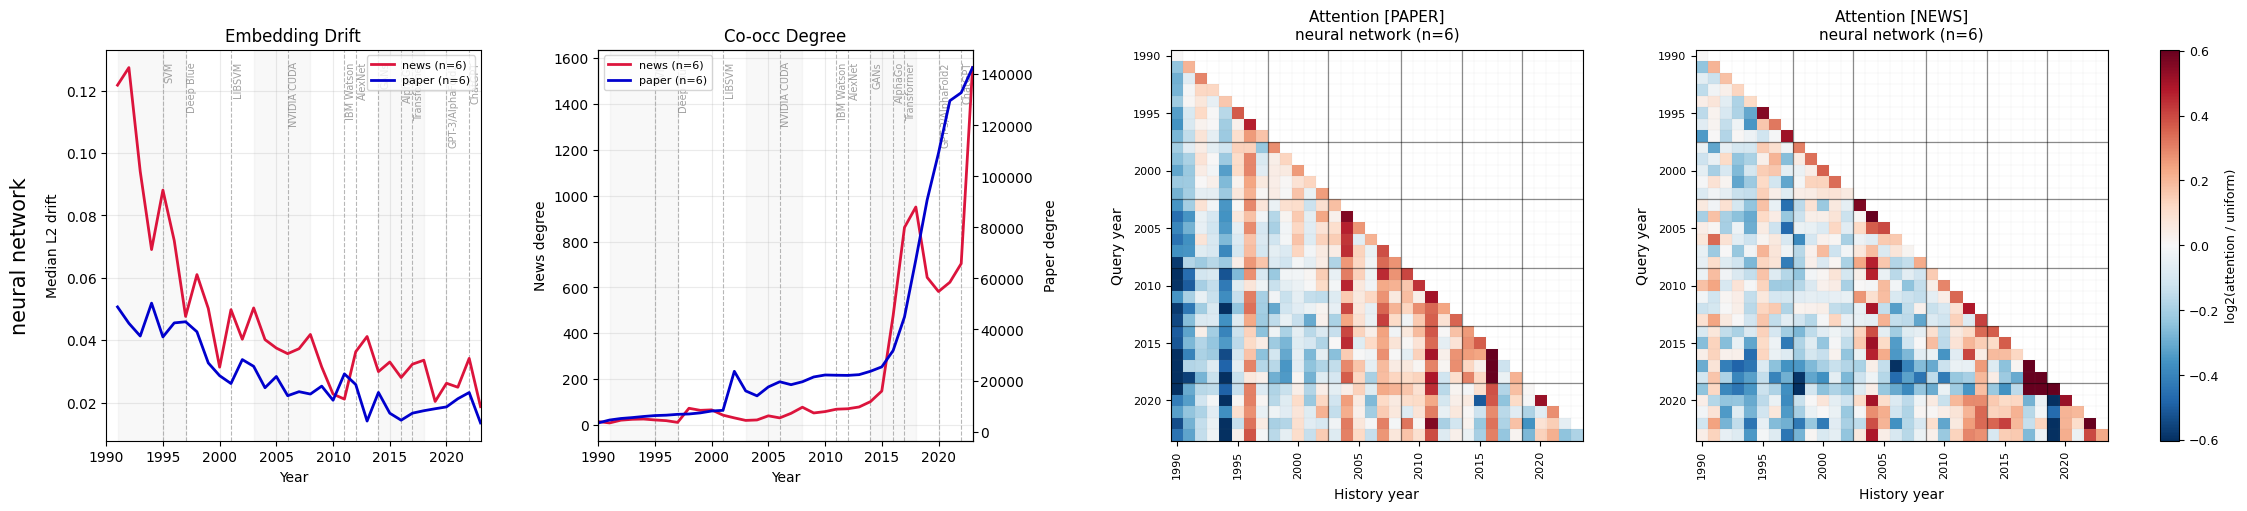

'privacy' [pooled] -> hits=12, using=12
  [ 13487] information privacy  score=10248.0
  [ 20969] privacy  score=8393.0
  [  7338] differential privacy  score=5387.0
  [ 20972] privacy protection  score=1762.0
  [ 22766] right of privacy  score=239.5
  [ 22771] right to privacy  score=224.6
  [  5275] computer privacy  score=223.6
  [  4153] chief privacy officers  score=194.0
  [ 14008] invasion of privacy  score=66.8
  [ 20970] privacy act 1974-us  score=42.0


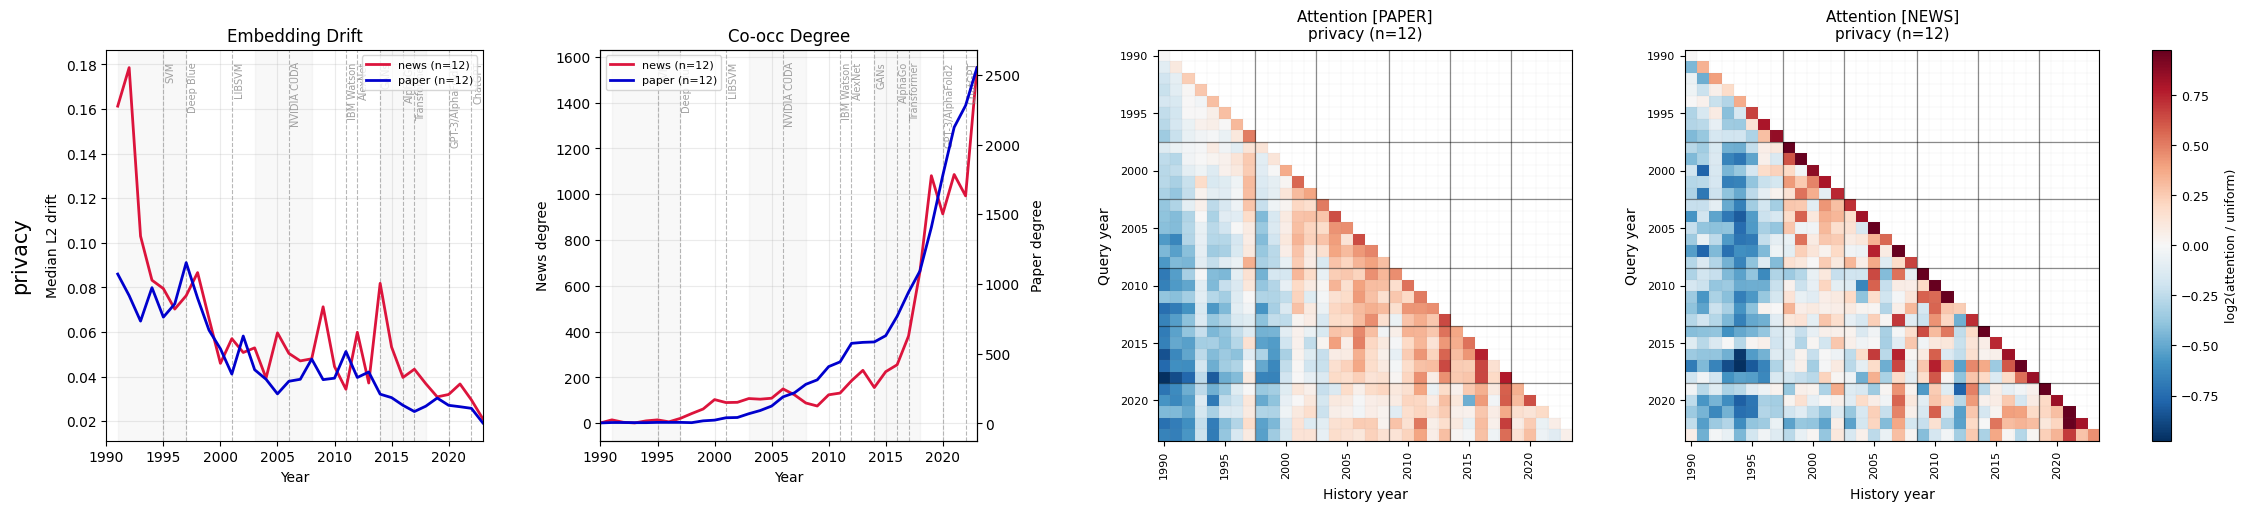

'employment' [pooled] -> hits=25, using=20
  [  8752] employment  score=10249.4
  [ 27794] unemployment  score=5466.8
  [ 27796] unemployment benefits  score=263.4
  [  8756] employment interviews  score=247.9
  [  8755] employment discrimination  score=241.6
  [ 27797] unemployment insurance  score=193.9
  [ 23605] self employment  score=135.6
  [  8753] employment agencies  score=134.5
  [  8759] employment security  score=126.3
  [ 23459] seasonal employment  score=73.0


In [ ]:
def plot_element_group(group_name, group_terms, save=True):
    group_idxs, missing = get_group_idxs(group_terms)
    if not group_idxs:
        print(f"[SKIP] {group_name}: no matching terms found. Missing={missing}")
        return None
    if missing:
        print(f"[WARN] {group_name}: missing terms = {missing}")

    group_drift = {src: np.nanmedian(drift[src].detach().cpu().numpy()[:, group_idxs], axis=1) for src in SOURCES}
    group_degree = {src: np.nansum(cooc_degree[src][:, group_idxs], axis=1) for src in SOURCES}
    group_attn_excess = {src: group_attention_excess(src, group_idxs) for src in SOURCES}

    vmax = max(np.nanpercentile(np.abs(group_attn_excess[src]), 98) for src in SOURCES)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    tick_pos = [k for k, y in enumerate(YEARS) if y % 5 == 0]
    tick_label = [str(YEARS[k]) for k in tick_pos]
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color="white")

    fig = plt.figure(figsize=(22, 5), constrained_layout=True)
    gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1.1, 1.1, 0.05], wspace=0.12)

    ax_drift = fig.add_subplot(gs[0, 0])
    ax_degree = fig.add_subplot(gs[0, 1])    
    ax_attn_paper = fig.add_subplot(gs[0, 2])
    ax_attn_news = fig.add_subplot(gs[0, 3])
    cax = fig.add_subplot(gs[0, 4])

    add_period_bands(ax_drift)
    ax_drift.plot(YEARS[1:], group_drift["news"],  color=NEWS_COLOR, lw=2, label=f"news (n={len(group_idxs)})")
    ax_drift.plot(YEARS[1:], group_drift["paper"], color=PAPER_COLOR, lw=2, label=f"paper (n={len(group_idxs)})")
    ax_drift.set(title="Embedding Drift", xlabel="Year", ylabel="Median L2 drift", xlim=(YEAR_START, YEAR_END))
    ax_drift.grid(alpha=0.25)
    add_events(ax_drift, fontsize=7)
    ax_drift.legend(fontsize=8, loc="upper right")

    add_period_bands(ax_degree)
    ln1 = ax_degree.plot(YEARS, group_degree["news"], color=NEWS_COLOR, lw=2, label=f"news (n={len(group_idxs)})")
    ax_degree.set(title="Co-occ Degree", xlabel="Year", ylabel="News degree", xlim=(YEAR_START, YEAR_END))
    ax_degree.grid(alpha=0.25)

    ax_degree_r = ax_degree.twinx()
    ln2 = ax_degree_r.plot(YEARS, group_degree["paper"], color=PAPER_COLOR, lw=2, label=f"paper (n={len(group_idxs)})")
    ax_degree_r.set_ylabel("Paper degree", labelpad=8)
    ax_degree_r.tick_params(axis="y", pad=2)
    add_events(ax_degree, fontsize=7)
    ax_degree.legend(ln1 + ln2, [line.get_label() for line in ln1 + ln2], fontsize=8, loc="upper left")

    for ax, src in [(ax_attn_news, "news"), (ax_attn_paper, "paper")]:
        im = ax.imshow(group_attn_excess[src], aspect="auto", origin="upper", cmap=cmap, norm=norm, interpolation="nearest")
        add_period_boundaries_heatmap(ax)

        T_local = len(YEARS)
        ax.set_xticks(np.arange(-0.5, T_local, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, T_local, 1), minor=True)
        ax.grid(which="minor", color="gray", lw=0.1, alpha=0.45)
        ax.tick_params(which="minor", bottom=False, left=False)

        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_label, fontsize=8, rotation=90)
        ax.set_yticks(tick_pos)
        ax.set_yticklabels(tick_label, fontsize=8)
        ax.set_xlabel("History year", labelpad=6)
        ax.set_ylabel("Query year", labelpad=6)
        ax.set_title(f"Attention [{src.upper()}]\n{group_name} (n={len(group_idxs)})", fontsize=11, pad=8)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("log2(attention / uniform)", fontsize=9)
    cbar.ax.tick_params(labelsize=9)

    fig.text(-0.01, 0.5, group_name, rotation=90,
         va="center", ha="center", fontsize=15)

    if save:
        safe_name = group_name.lower().replace(" ", "_").replace("/", "_")
        plt.savefig(OUT_DIR / f"element_dynamics_{safe_name}.png", dpi=300, bbox_inches="tight")

    plt.show()
    return fig

for group_name, (query, top_k) in ELEMENT_QUERIES.items():
    terms = get_group_terms(query, top_k=top_k, src=None, verbose=True)
    plot_element_group(group_name, terms)